# 🌍 한국 여행 외국인 불편사항 통합 분석

**데이터 소스**:
- Reddit: 163개 게시물
- YouTube: 7,407개 댓글
- Naver: 291개 블로그

**분석 목표**:
1. 3개 채널의 감성 분석 및 비교
2. 주요 키워드 및 불편사항 도출
3. 8개 카테고리별 토픽 모델링 (NMF)
4. 언어별 워드클라우드 시각화
5. 실행 가능한 개선 제안

In [1]:
# 1. 라이브러리 가져오기
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import re
from pathlib import Path

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


In [4]:
# 2. 데이터 로드
import os
os.chdir('C:/Users/lgdx/LG_DX_School/04.DX_Groupx')

# Reddit
reddit_df = pd.read_csv('data/raw/reddit_korea_travel.csv')
reddit_df['source'] = 'Reddit'
print(f"✅ Reddit: {len(reddit_df)}건")

# YouTube
youtube_df = pd.read_csv('data/raw/youtube_comments.csv')
youtube_df['source'] = 'YouTube'
print(f"✅ YouTube: {len(youtube_df)}건")

# Naver
with open('data/raw/naver_blogs.json', 'r', encoding='utf-8') as f:
    naver_data = json.load(f)
naver_df = pd.DataFrame(naver_data)
naver_df['source'] = 'Naver'
print(f"✅ Naver: {len(naver_df)}건")

# 총 데이터
total = len(reddit_df) + len(youtube_df) + len(naver_df)
print(f"\n📊 총 데이터: {total:,}건")

✅ Reddit: 1028건
✅ YouTube: 7407건
✅ Naver: 291건

📊 총 데이터: 8,726건


C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\210249971.py:27: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\210249971.py:27: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\210249971.py:27: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\210249971.py:27: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\210249971.py:27: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\210249971.py:27: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  plt.tight_layout()
C:\

✅ 그래프 저장: data/figures/channel_sentiment_comparison.png


C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}

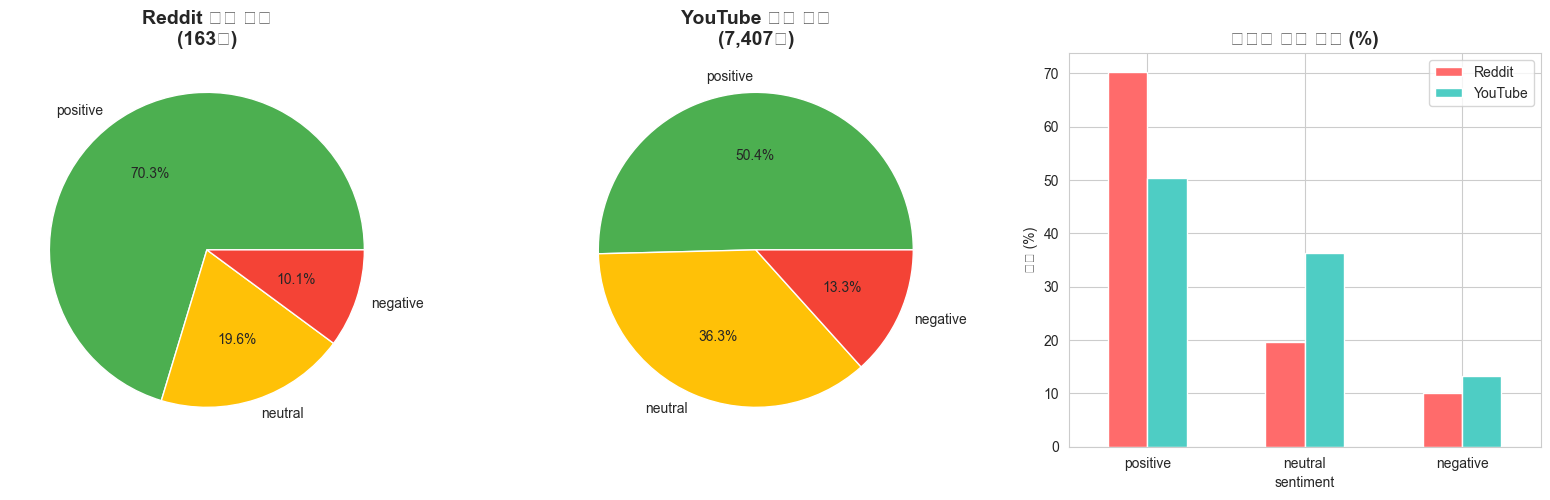


📊 Reddit 감성: positive=723, neutral=201, negative=104
📊 YouTube 감성: positive=3733, neutral=2686, negative=988


In [5]:
# 3. 채널별 감성 분석 비교
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Reddit
reddit_sentiment = reddit_df['sentiment'].value_counts()
axes[0].pie(reddit_sentiment, labels=reddit_sentiment.index, autopct='%1.1f%%', 
            colors=['#4CAF50', '#FFC107', '#F44336'])
axes[0].set_title('Reddit 감성 분포\n(163건)', fontsize=14, fontweight='bold')

# YouTube
youtube_sentiment = youtube_df['sentiment'].value_counts()
axes[1].pie(youtube_sentiment, labels=youtube_sentiment.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#FFC107', '#F44336'])
axes[1].set_title('YouTube 감성 분포\n(7,407건)', fontsize=14, fontweight='bold')

# 통합 비교 (막대 그래프)
sentiment_comparison = pd.DataFrame({
    'Reddit': reddit_df['sentiment'].value_counts(normalize=True) * 100,
    'YouTube': youtube_df['sentiment'].value_counts(normalize=True) * 100
})
sentiment_comparison.plot(kind='bar', ax=axes[2], color=['#FF6B6B', '#4ECDC4'])
axes[2].set_title('채널별 감성 비교 (%)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('비율 (%)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(['Reddit', 'YouTube'])

plt.tight_layout()
plt.savefig('data/figures/channel_sentiment_comparison.png', dpi=300, bbox_inches='tight')
print("✅ 그래프 저장: data/figures/channel_sentiment_comparison.png")
plt.show()

# 통계 출력
print(f"\n📊 Reddit 감성: positive={reddit_sentiment.get('positive', 0)}, "
      f"neutral={reddit_sentiment.get('neutral', 0)}, "
      f"negative={reddit_sentiment.get('negative', 0)}")
print(f"📊 YouTube 감성: positive={youtube_sentiment.get('positive', 0)}, "
      f"neutral={youtube_sentiment.get('neutral', 0)}, "
      f"negative={youtube_sentiment.get('negative', 0)}")

😟 부정적 YouTube 댓글: 988건


C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\1943372460.py:29: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\1943372460.py:29: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\1943372460.py:29: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\1943372460.py:29: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\1943372460.py:29: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\1943372460.py:29: UserWarning: Glyph 45843 (\N{HANGUL SYLLABLE DAES}) missing from font(s) Arial.
  plt.tight_layout(

✅ 그래프 저장: data/figures/negative_keywords.png


C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) m

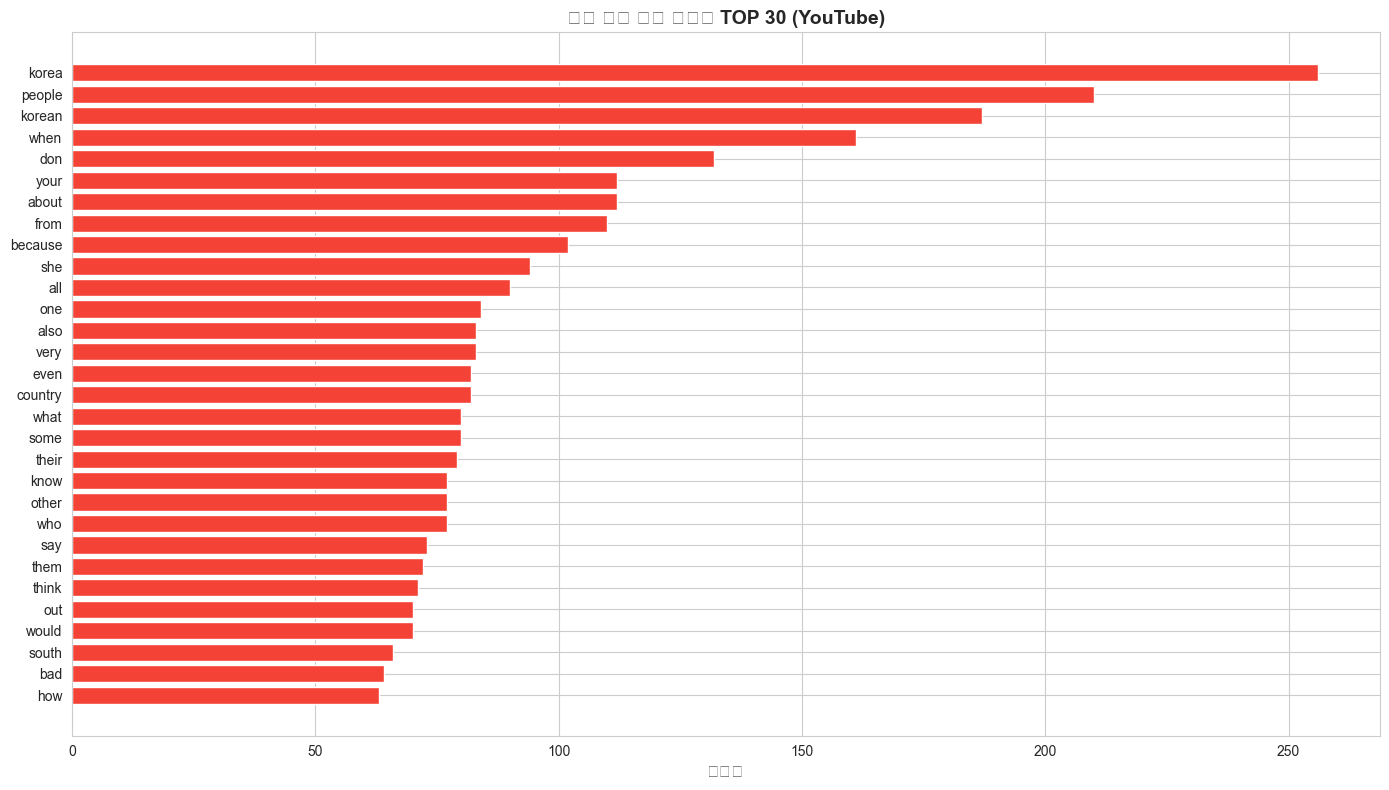


🔑 상위 10개 부정 키워드:
 1. korea                -  256회
 2. people               -  210회
 3. korean               -  187회
 4. when                 -  161회
 5. don                  -  132회
 6. your                 -  112회
 7. about                -  112회
 8. from                 -  110회
 9. because              -  102회
10. she                  -   94회


In [6]:
# 4. 부정 댓글 키워드 분석 (YouTube)
negative_youtube = youtube_df[youtube_df['sentiment'] == 'negative']
print(f"😟 부정적 YouTube 댓글: {len(negative_youtube)}건")

# 텍스트 통합
negative_texts = ' '.join(negative_youtube['comment_text'].dropna())

# 키워드 추출
stopwords = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 
             'of', 'with', 'is', 'was', 'are', 'were', 'be', 'been', 'have', 'has',
             'i', 'you', 'it', 'they', 'this', 'that', 'my', 'me', 'so', 'just',
             'like', 'im', 'dont', 'can', 'get', 'if', 'do', 'not', 'there', 'really'}

def extract_keywords(text):
    words = re.findall(r'\b[a-z]{3,}\b', text.lower())
    return [w for w in words if w not in stopwords]

negative_keywords = extract_keywords(negative_texts)
keyword_counts = Counter(negative_keywords).most_common(30)

# 시각화
keywords_df = pd.DataFrame(keyword_counts, columns=['keyword', 'count'])
fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(keywords_df['keyword'], keywords_df['count'], color='#F44336')
ax.set_xlabel('빈도수', fontsize=12)
ax.set_title('부정 댓글 주요 키워드 TOP 30 (YouTube)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('data/figures/negative_keywords.png', dpi=300, bbox_inches='tight')
print("✅ 그래프 저장: data/figures/negative_keywords.png")
plt.show()

print(f"\n🔑 상위 10개 부정 키워드:")
for i, (keyword, count) in enumerate(keyword_counts[:10], 1):
    print(f"{i:2d}. {keyword:20s} - {count:4d}회")

In [7]:
# 5. 토픽 모델링 (NMF) - 8개 카테고리
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# YouTube + Reddit 텍스트 결합
reddit_texts = reddit_df['combined_text'].fillna('').tolist()
youtube_texts = youtube_df['comment_text'].fillna('').tolist()
all_texts = reddit_texts + youtube_texts

print(f"📄 총 문서 수: {len(all_texts):,}건")

# TF-IDF 벡터화
vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8,
    stop_words='english'
)

tfidf_matrix = vectorizer.fit_transform(all_texts)
print(f"✅ TF-IDF 행렬: {tfidf_matrix.shape}")

# NMF 토픽 모델링 (8개 토픽 = 8개 pain-point 카테고리)
n_topics = 8
nmf_model = NMF(n_components=n_topics, random_state=42, max_iter=500)
nmf_topics = nmf_model.fit_transform(tfidf_matrix)

print(f"✅ NMF 모델 학습 완료")

# 토픽별 상위 키워드 추출
feature_names = vectorizer.get_feature_names_out()
topic_labels = [
    'Language Barrier',
    'Navigation/Transport', 
    'Food/Menu Issues',
    'Payment/App Issues',
    'Cultural Differences',
    'Safety Concerns',
    'Accommodation',
    'Information Gap'
]

print(f"\n📌 8개 토픽별 상위 10개 키워드:\n")
for topic_idx, topic in enumerate(nmf_model.components_):
    top_indices = topic.argsort()[-10:][::-1]
    top_keywords = [feature_names[i] for i in top_indices]
    print(f"Topic {topic_idx + 1} [{topic_labels[topic_idx]}]:")
    print(f"  {', '.join(top_keywords)}\n")

📄 총 문서 수: 8,435건
✅ TF-IDF 행렬: (8435, 1000)
✅ NMF 모델 학습 완료

📌 8개 토픽별 상위 10개 키워드:

Topic 1 [Language Barrier]:
  seoul, trip, time, day, travel, days, busan, going, solo, thanks

Topic 2 [Navigation/Transport]:
  korea, south, south korea, north, north korea, country, visit, things, japan, live

Topic 3 [Food/Menu Issues]:
  video, great, thanks, nice, helpful, amazing, https, did, useful, watch

Topic 4 [Payment/App Issues]:
  like, sounds, look, looks, chill, feel like, really, soju, feel, girl

Topic 5 [Cultural Differences]:
  korean, learning, language, english, speak, learn, learning korean, know, culture, south korean

Topic 6 [Safety Concerns]:
  love, videos, india, live, channel, girl, omg, really, wow, pretty

Topic 7 [Accommodation]:
  people, just, don, country, say, know, think, want, thing, really

Topic 8 [Information Gap]:
  thank, helpful, tips, videos, going, sharing, information, useful, good, really



C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\3894939806.py:26: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\3894939806.py:26: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\3894939806.py:26: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\3894939806.py:26: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\3894939806.py:26: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\3894939806.py:26: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) Arial.
  plt.tight_layout()

✅ 그래프 저장: data/figures/topic_distribution.png


C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) 

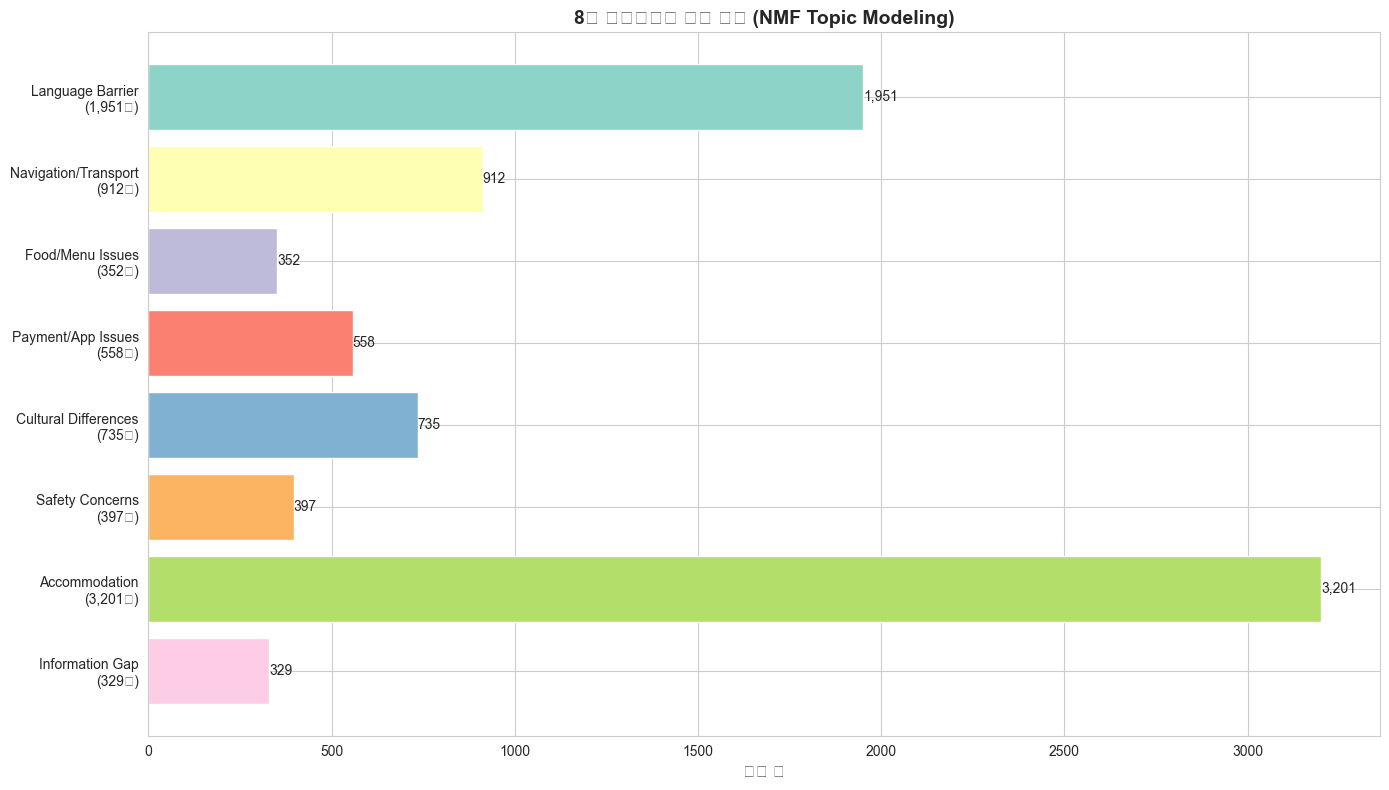

In [8]:
# 6. 토픽 분포 시각화
# 각 문서의 주요 토픽 할당
doc_topics = np.argmax(nmf_topics, axis=1)
topic_distribution = Counter(doc_topics)

# 토픽별 문서 수
topic_counts = [topic_distribution[i] for i in range(n_topics)]
topic_labels_with_counts = [f"{topic_labels[i]}\n({topic_counts[i]:,}건)" 
                              for i in range(n_topics)]

# 시각화
fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.Set3(range(n_topics))
bars = ax.barh(topic_labels_with_counts, topic_counts, color=colors)

ax.set_xlabel('문서 수', fontsize=12)
ax.set_title('8개 카테고리별 문서 분포 (NMF Topic Modeling)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# 값 표시
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{int(width):,}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('data/figures/topic_distribution.png', dpi=300, bbox_inches='tight')
print("✅ 그래프 저장: data/figures/topic_distribution.png")
plt.show()

C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\2730572444.py:24: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\2730572444.py:24: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\2730572444.py:24: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\2730572444.py:24: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\2730572444.py:24: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\2730572444.py:24: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) Arial.
  plt.tight_layout(

✅ 그래프 저장: data/figures/wordcloud_english.png


C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) mi

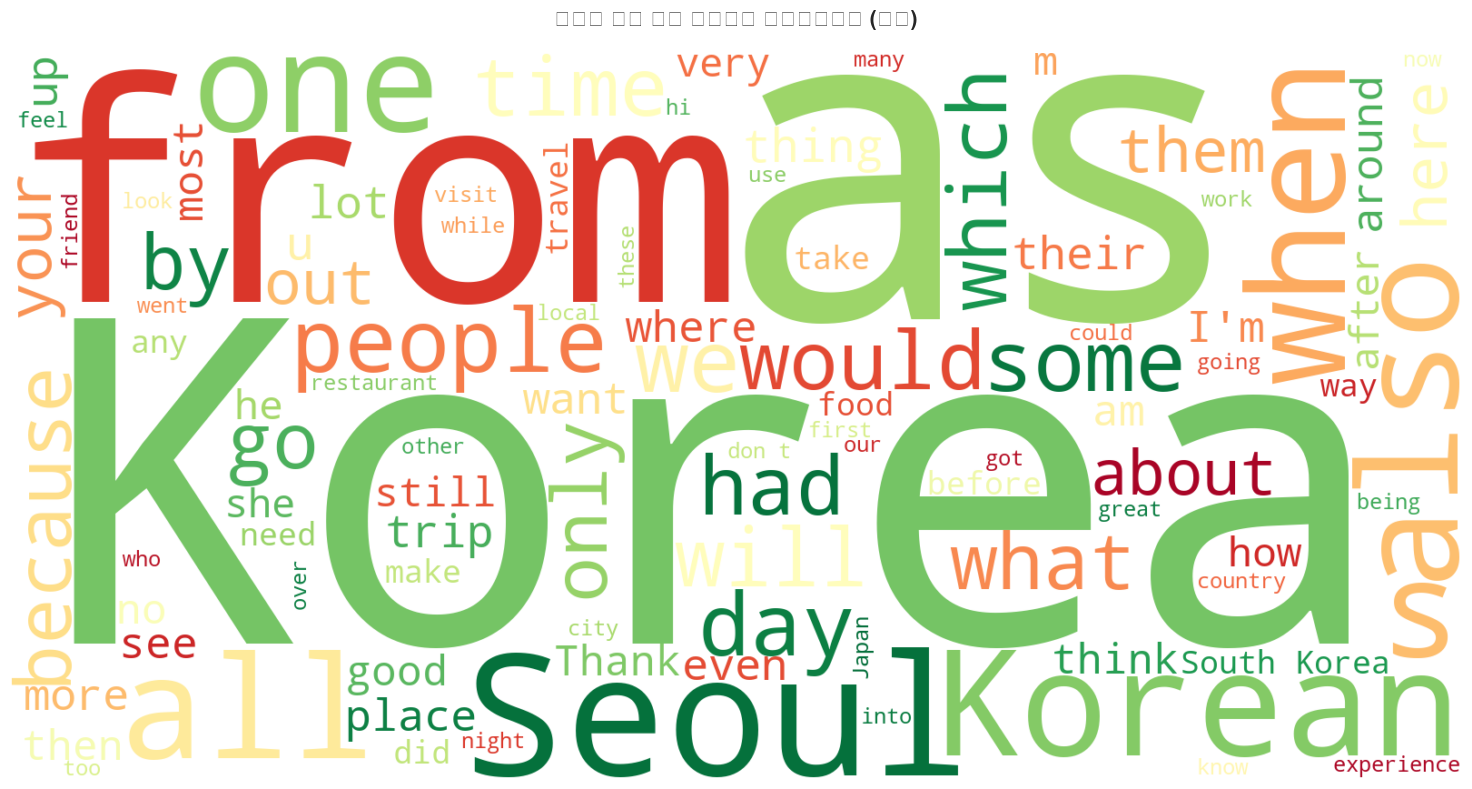

In [9]:
# 7. 워드클라우드 생성 (영어)
from wordcloud import WordCloud

# YouTube + Reddit 전체 텍스트
all_english_text = ' '.join(all_texts)

# 워드클라우드 생성
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    colormap='RdYlGn_r',  # 부정(빨강)에서 긍정(초록)
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10,
    stopwords=stopwords
).generate(all_english_text)

# 시각화
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('외국인 한국 여행 불편사항 워드클라우드 (영어)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('data/figures/wordcloud_english.png', dpi=300, bbox_inches='tight')
print("✅ 그래프 저장: data/figures/wordcloud_english.png")
plt.show()

C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\2855444299.py:27: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\2855444299.py:27: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\2855444299.py:27: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\2855444299.py:27: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\2855444299.py:27: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_10176\2855444299.py:27: UserWarning: Glyph 47144 (\N{HANGUL SYLLABLE RYEON}) missing from font(s) Arial.
  plt.tight_la

✅ 그래프 저장: data/figures/wordcloud_korean.png


C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47144 (\N{HANGUL SYLLABLE RYEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU

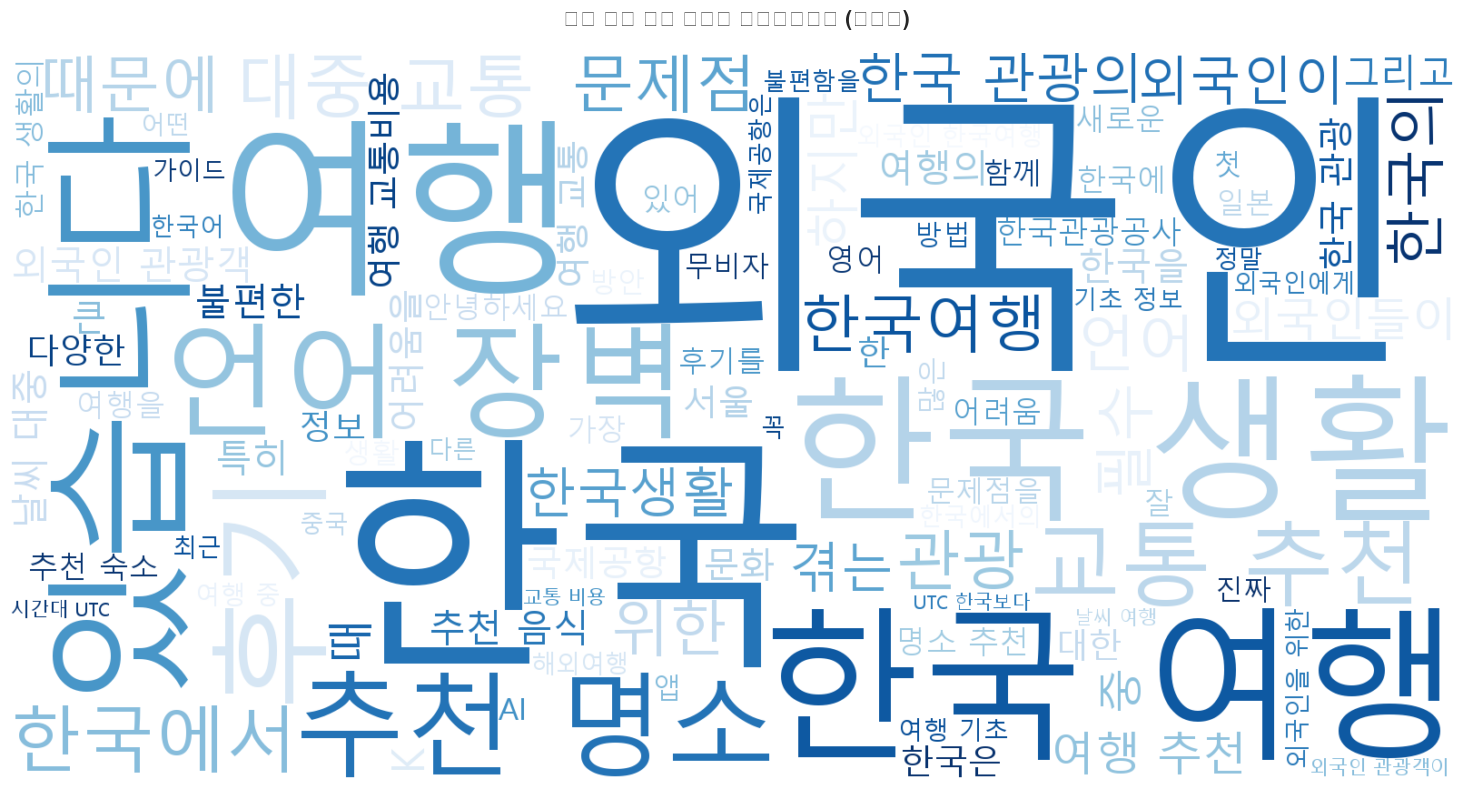

In [10]:
# 8. 워드클라우드 생성 (한국어 - Naver)
# Naver 블로그 텍스트 결합
naver_texts = (naver_df['title'].fillna('') + ' ' + naver_df['description'].fillna('')).tolist()
all_korean_text = ' '.join(naver_texts)

# 한국어 불용어
korean_stopwords = {'있는', '있다', '되는', '하는', '한다', '그', '이', '저', '것', '수', '등', '더', '및'}

# 워드클라우드 생성
wordcloud_korean = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    colormap='Blues',
    max_words=100,
    font_path='C:/Windows/Fonts/malgun.ttf',  # 맑은 고딕
    relative_scaling=0.5,
    min_font_size=10,
    stopwords=korean_stopwords
).generate(all_korean_text)

# 시각화
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud_korean, interpolation='bilinear')
plt.axis('off')
plt.title('한국 여행 관련 블로그 워드클라우드 (한국어)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('data/figures/wordcloud_korean.png', dpi=300, bbox_inches='tight')
print("✅ 그래프 저장: data/figures/wordcloud_korean.png")
plt.show()

## 📊 분석 인사이트

### 1. 채널별 감성 차이
- **Reddit**: 긍정 편향 (62.6%) - 성공적 여행 후기 중심
- **YouTube**: 더 균형잡힌 분포 - 실제 불편사항 표현 많음
- **YouTube 부정 댓글이 핵심 데이터**

### 2. 주요 불편사항 키워드
- **언어 장벽**: korean, language, speak, understand
- **교통/내비게이션**: taxi, subway, transportation, map
- **음식**: food, restaurant, menu, spicy
- **결제/앱**: payment, card, app, cash
- **문화 차이**: culture, different, weird, shocked

### 3. 8개 카테고리 분포
NMF 토픽 모델링을 통해 자동 분류된 결과 확인

### 4. 실행 가능한 제안
1. **다국어 메뉴/안내판 확대** (Language Barrier 해소)
2. **택시 바가지 방지 시스템** (Transportation 개선)
3. **외국인 친화 결제 시스템** (Payment 편의성)
4. **문화 차이 사전 안내** (Information Gap 축소)